# I Love Python

Diego Lozoya Morales | 745345

# Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

import warnings
warnings.filterwarnings("ignore")

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.5
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

colors = ["#6495ed", "#cd5c5c"]

custom_cmap = mcolors.LinearSegmentedColormap.from_list(
    "blue_scale",
    [colors[0], colors[-1]]
)

# Data

In [2]:
data_train = pd.read_csv('Data/trainData.csv')
data_test = pd.read_csv('Data/testData.csv')

data_train

,id,creditLimit,gender,edu,age,nDelay,billAmt1,billAmt2,billAmt3,billAmt4,billAmt5,billAmt6,default
0,1,4500,0,2,28,0,3915,3150,2475,2340,2385,2430,0
1,2,6000,0,2,24,0,2820,2700,2760,2400,2280,2280,1
2,3,3800,0,2,39,0,3572,3648,3762,2166,2204,2242,0
3,4,5500,1,1,27,0,5280,5445,5390,2585,2640,2695,1
4,5,18000,1,1,51,2,3780,3780,3780,1800,1620,720,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,1996,18000,1,1,34,0,180,180,180,180,180,180,0
1996,1997,33300,1,1,34,0,333,333,2664,333,333,2331,0
1997,1998,33000,1,2,35,0,18150,17820,17490,15510,15840,15840,1
1998,1999,18200,1,1,36,0,182,364,0,182,182,182,0


In [3]:
data_test

,id,creditLimit,gender,edu,age,nDelay,billAmt1,billAmt2,billAmt3,billAmt4,billAmt5,billAmt6,default
0,1,1500,0,3,31,2,1350,1530,1455,1515,1530,1515,0
1,2,10900,0,1,47,0,8720,9047,9374,0,0,2834,0
2,3,3600,1,2,54,3,2520,2448,2808,2736,2700,2880,1
3,4,4200,0,1,25,0,4116,3990,3906,1764,1722,1722,0
4,5,19200,0,5,53,0,12864,13056,12864,6144,3840,11904,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,4200,1,3,53,0,6384,6468,6594,6678,1638,1680,0
996,997,4500,1,2,26,0,1575,540,1485,360,0,0,0
997,998,7300,1,2,28,1,0,0,0,2117,2263,2409,0
998,999,3600,0,3,55,0,1800,1908,1944,1980,2016,2088,0


## Dependent / Independent variables

In [4]:
target = 'default'

# Train split
X_train = data_train.drop(columns=['id', target])
y_train = data_train[target]

# Test split
X_test = data_test.drop(columns=['id', target])
y_test = data_test[target]

# Variables Interactions

In [5]:
def scatter_plot(df: pd.DataFrame, feature1: str, feature2: str) -> None:
    plt.figure()
    plt.scatter(df[feature1], df[feature2], c=y_train, cmap=custom_cmap, alpha=0.5)
    plt.title(f'Scatter Plot: {feature1} vs {feature2}')
    plt.xlabel(feature1)
    plt.ylabel(feature2)
    plt.colorbar(label='Default')
    plt.show()

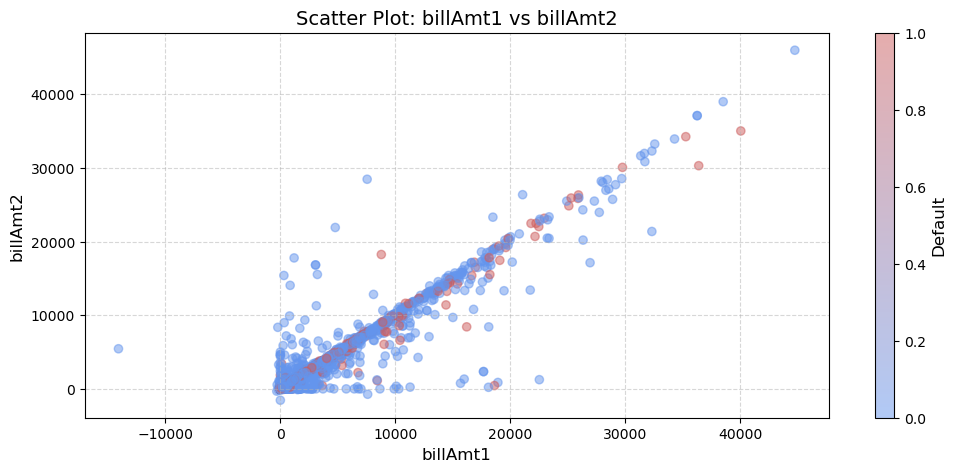

In [6]:
scatter_plot(data_train, 'billAmt1', 'billAmt2')

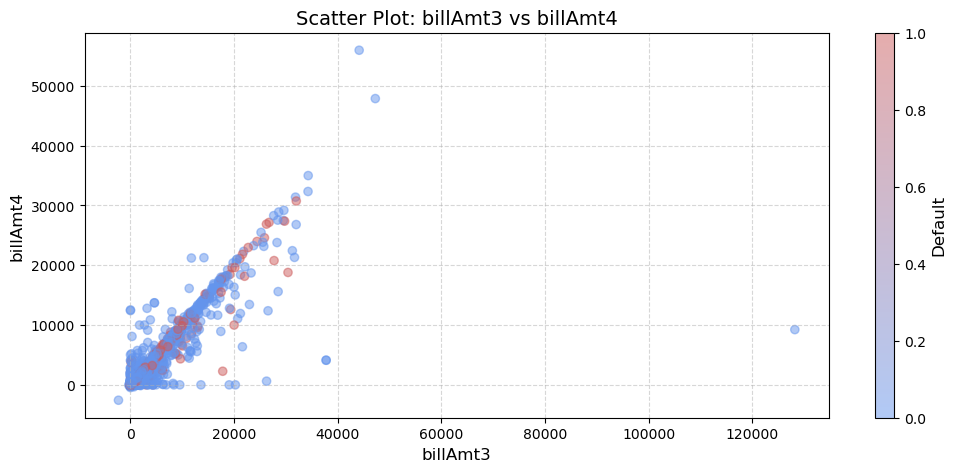

In [7]:
scatter_plot(data_train, 'billAmt3', 'billAmt4')

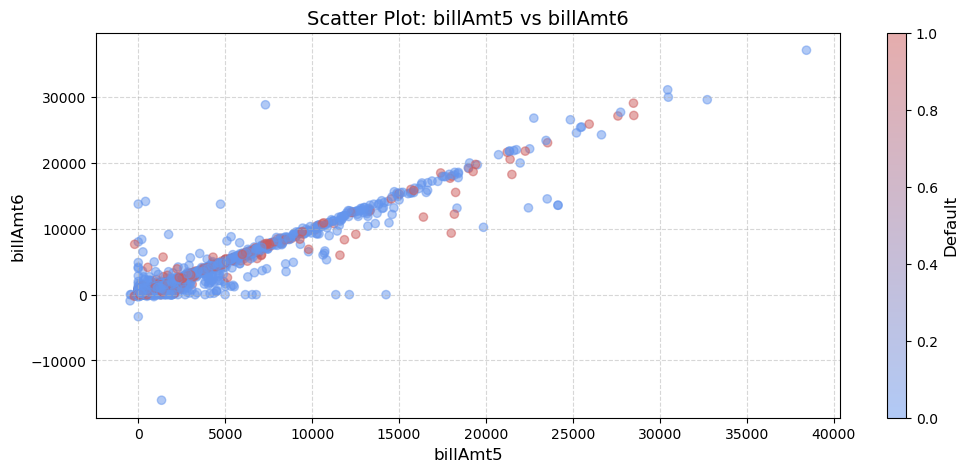

In [8]:
scatter_plot(data_train, 'billAmt5', 'billAmt6')

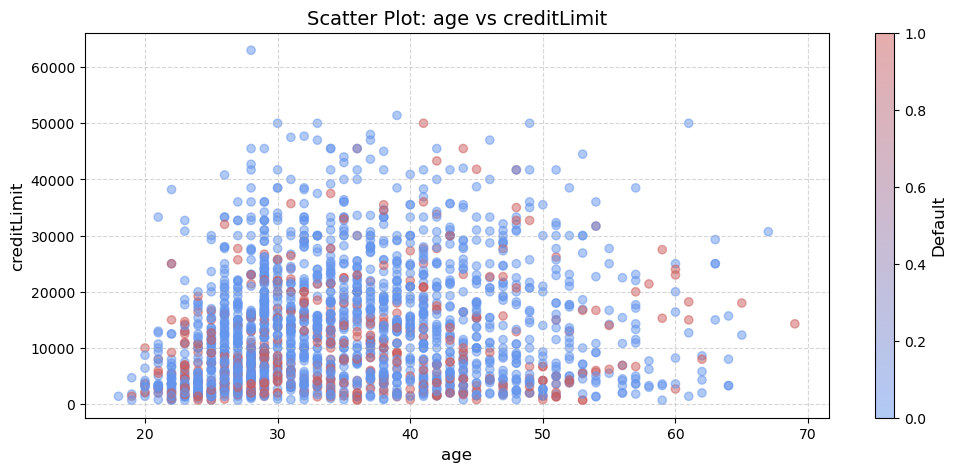

In [9]:
scatter_plot(data_train, 'age', 'creditLimit')

# Models

In [10]:
def roc(probabilidades, y_test, model_name):
    fpr, tpr, _ = roc_curve(y_score=probabilidades, y_true=y_test)
    
    plt.figure()
    plt.plot(fpr, tpr, color=colors[0], lw=2, label='ROC curve')
    plt.fill_between(fpr, tpr, alpha=0.15, color=colors[0])
    plt.plot([0, 1], [0, 1], color=colors[1], linestyle='--', lw=2, label='Random Classifier')
    plt.xlabel('1 - Specificity (FPR)')
    plt.ylabel('Sensitivity (TPR)')
    plt.title(f'ROC curve {model_name} - AUC: {roc_auc_score(y_test, probabilidades):.2f}')
    plt.legend()
    plt.show()

## Logistic Regresion

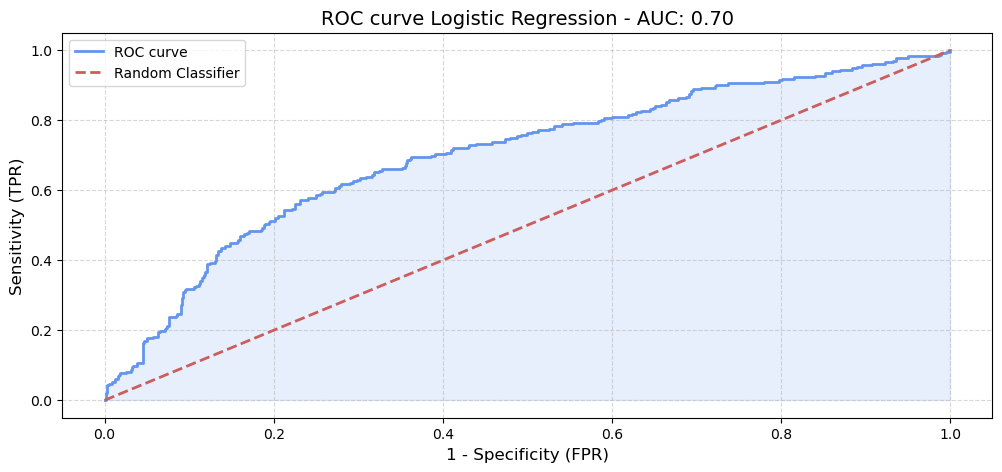

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.97      0.86       768
           1       0.47      0.08      0.14       232

    accuracy                           0.77      1000
   macro avg       0.63      0.53      0.50      1000
weighted avg       0.71      0.77      0.70      1000



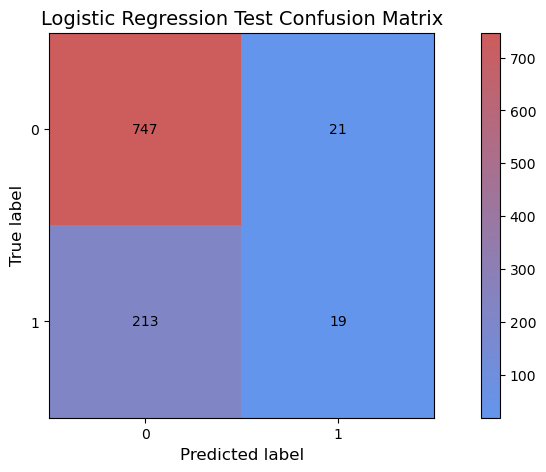

In [11]:
# Model
lr = LogisticRegression()
lr.fit(X_train, y_train)

# Predictions
y_pred_lr = lr.predict(X_test)
y_proba_lr = lr.predict_proba(X_test)[:, 1]

# ROC Curve
roc(y_proba_lr, y_test, "Logistic Regression")

# Report
print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_lr))

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr,
    display_labels=[0, 1],
    cmap=custom_cmap,
    text_kw={'color': 'black'}
)
plt.title('Logistic Regression Test Confusion Matrix')
plt.grid(False)
plt.show()

## XGBoost

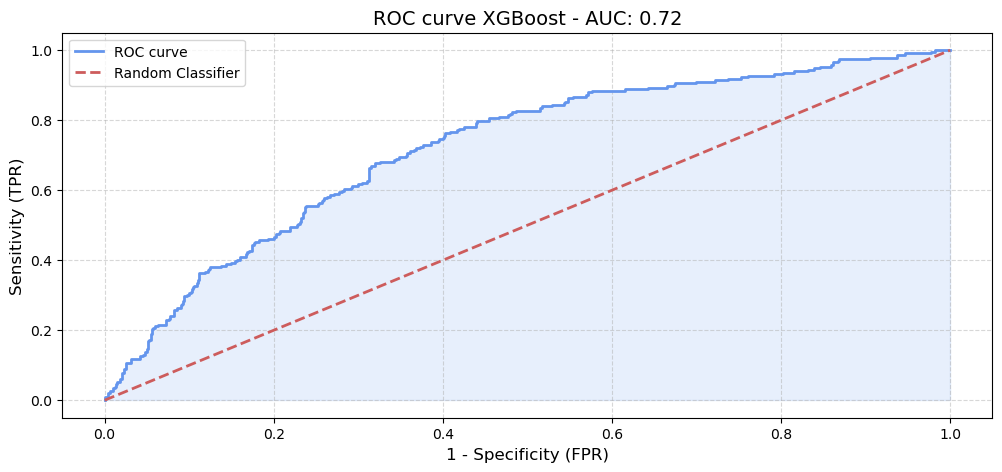

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.91      0.85       768
           1       0.47      0.27      0.35       232

    accuracy                           0.76      1000
   macro avg       0.64      0.59      0.60      1000
weighted avg       0.73      0.76      0.74      1000



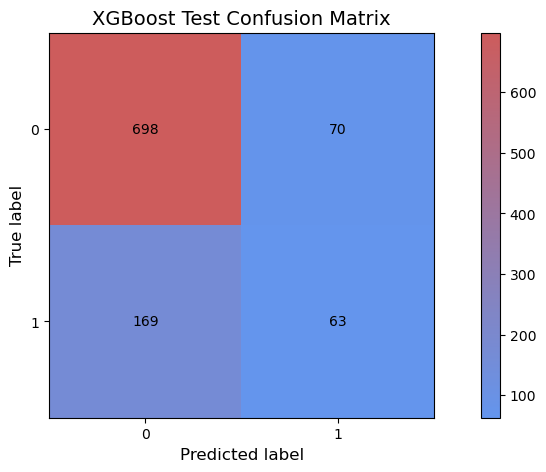

In [12]:
# Model
xgb = XGBClassifier()
xgb.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

# ROC Curve
roc(y_proba_xgb, y_test, "XGBoost")

# Report
print("XGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb))

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_xgb,
    display_labels=[0, 1],
    cmap=custom_cmap,
    text_kw={'color': 'black'}
)
plt.title('XGBoost Test Confusion Matrix')
plt.grid(False)
plt.show()